# 04 - Evaluacion del modelo

Este notebook calcula las metricas de error sobre el conjunto de prueba y genera los graficos
finales de evaluacion.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = 'produccion_toneladas'
FEATURES = ['año', 'id_municipio', 'subregion']
SEED = 42

# Localizar la raiz del proyecto
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / 'frutales_limpias.csv')

X = pd.get_dummies(df[FEATURES], drop_first=True)
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
residuos = y_test - y_pred


## Metricas en test


In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metricas = pd.DataFrame({
    'Metrica': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Valor': [mae, mse, rmse, r2]
})
metricas


,Metrica,Valor
0,MAE,4.838094e+03
1,MSE,6.805250e+07
2,RMSE,8.249394e+03
3,R²,1.908833e-01


`MAE` y `RMSE` estan en las mismas unidades que la produccion (toneladas). El `R²` indica la
proporcion de varianza explicada; valores bajos son esperables con predictores tan simples.


## Graficos de evaluacion


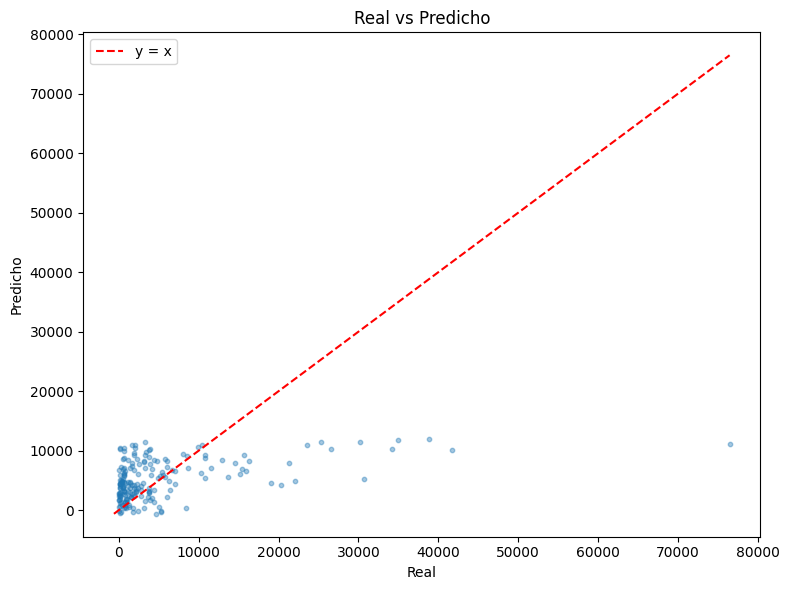

In [8]:
# (a) Real vs predicho, con linea y = x
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='y = x')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'real_vs_predicho.png', dpi=150)
plt.show()


Si el modelo fuera perfecto, todos los puntos caerian sobre la linea `y = x`. Los puntos lejos
de la diagonal representan errores grandes.


Predictor numerico mas correlacionado: año | corr = 0.171


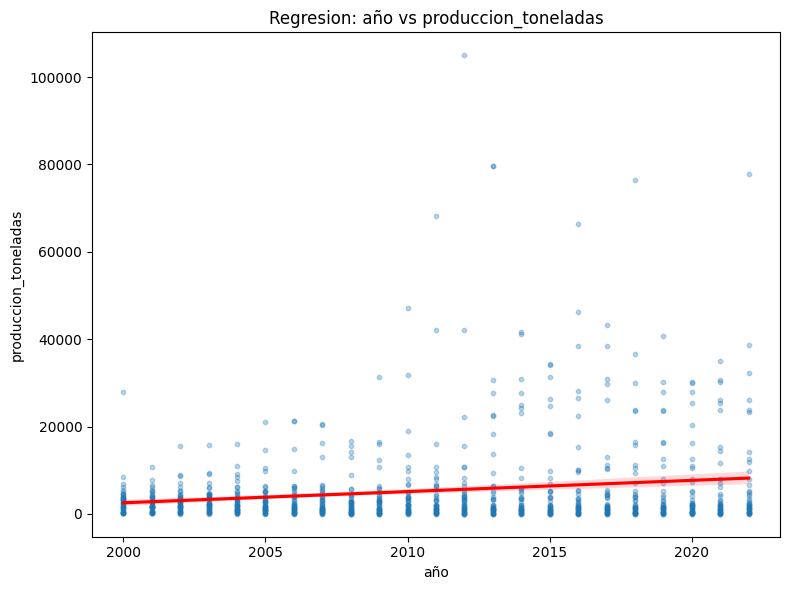

In [9]:
# (b) Scatter + recta de regresion del predictor numerico mas correlacionado
cols_num = [c for c in FEATURES if df[c].dtype.kind in 'if']
corr = df[cols_num + [TARGET]].corr()[TARGET].drop(TARGET)
mas_corr = corr.abs().idxmax()
print('Predictor numerico mas correlacionado:', mas_corr, '| corr =', round(corr[mas_corr], 4))

plt.figure(figsize=(8, 6))
sns.regplot(
    x=df[mas_corr], y=df[TARGET],
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'red'}
)
plt.title(f'Regresion: {mas_corr} vs {TARGET}')
plt.tight_layout()
plt.savefig(FIGURES / 'regresion_predictor_top.png', dpi=150)
plt.show()


La recta roja muestra la relacion lineal simple entre el predictor numerico mas correlacionado y
el objetivo; una pendiente casi plana indica una relacion debil.


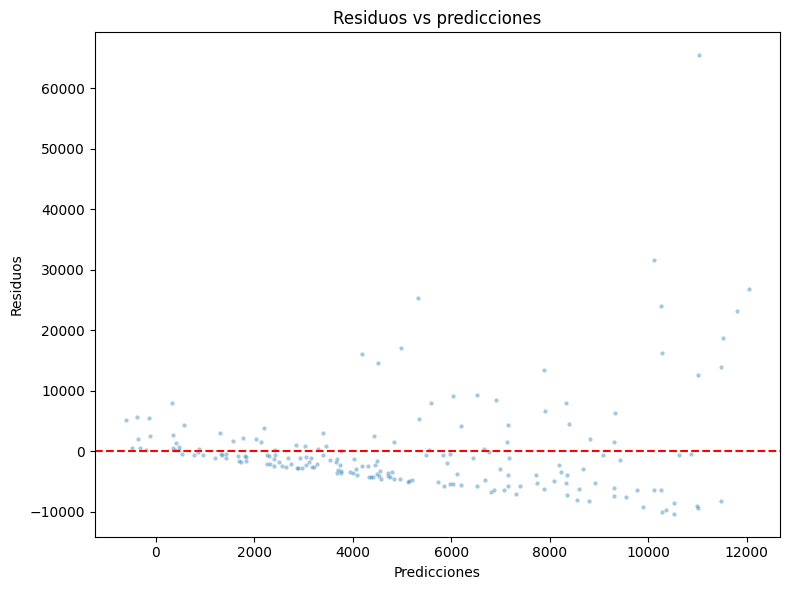

In [10]:
# (c) Residuos vs predicciones
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuos, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.tight_layout()
plt.savefig(FIGURES / 'evaluacion_residuos.png', dpi=150)
plt.show()


Este grafico confirma el patron ya visto en el notebook 03: residuos sin estructura clara
indicarian que el modelo lineal es adecuado.
